# 4. Norms and Inner Products

How long is a vector?  How do we measure the angle between two vectors?  
These questions are answered by **norms** and **inner products** -- the rulers and protractors of linear algebra.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

BLUE = "#2196F3"
RED  = "#F44336"
GREEN = "#4CAF50"
ORANGE = "#FF9800"

def setup_ax(ax, lim=3, title=""):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.grid(True, lw=0.4, alpha=0.5)
    ax.axhline(0, color="k", lw=0.4)
    ax.axvline(0, color="k", lw=0.4)
    if title:
        ax.set_title(title, fontsize=13)

## 4.1 Vector Norms

A **norm** $\|\mathbf{v}\|$ assigns a non-negative "size" to every vector.  The most common family is the **$L^p$ norm**:

$$\|\mathbf{v}\|_p = \left( \sum_i |v_i|^p \right)^{1/p}$$

| Name | $p$ | Formula (2D) | Intuition |
|------|-----|-------------|----------|
| $L^1$ (Manhattan) | 1 | $|v_x| + |v_y|$ | Taxi-cab distance |
| $L^2$ (Euclidean) | 2 | $\sqrt{v_x^2 + v_y^2}$ | Straight-line distance |
| $L^\infty$ (Chebyshev) | $\infty$ | $\max(|v_x|, |v_y|)$ | Chessboard distance |

**Ordering rule:** for any fixed vector, $\|\mathbf{v}\|_\infty \le \|\mathbf{v}\|_2 \le \|\mathbf{v}\|_1$.

In [2]:
v = np.array([3, 4])
# say we have two vectors, (3,4) and (9,2), we need to transpose them to make them a matrix
v = np.array([[3,9], [4,2]])
print(f"{v=}")
print(f"  L1  norm: {np.linalg.norm(v, 1):.2f}")
print(f"  L2  norm: {np.linalg.norm(v, 2):.2f}")
print(f"  Linf norm: {np.linalg.norm(v, np.inf):.2f}")

v=array([[3, 9],
       [4, 2]])
  L1  norm: 11.00
  L2  norm: 10.05
  Linf norm: 12.00


## 4.2 Unit Balls -- Geometry of Norms

The **unit ball** for norm $p$ is the set of all vectors with $\|\mathbf{v}\|_p \le 1$.  
Its boundary (the unit sphere) is the set where $\|\mathbf{v}\|_p = 1$.

Different norms give very different shapes:
- $p = 1$: a diamond
- $p = 2$: a circle
- $p = \infty$: a square

Use the slider to sweep $p$ and watch the shape morph.

In [ ]:
def unit_ball_boundary(p, n=500):
    """
    Compute boundary points of the 2D Lp unit ball.

    Parameters
    ----------
    p : float
        Norm order (>= 1).
    n : int
        Number of boundary samples.

    Returns
    -------
    ndarray, shape (n, 2)
    """
    theta = np.linspace(0, 2 * np.pi, n)
    raw = np.column_stack([np.cos(theta), np.sin(theta)])
    norms = np.sum(np.abs(raw) ** p, axis=1) ** (1 / p)
    return raw / norms[:, None]


def plot_unit_ball(p):
    fig, ax = plt.subplots(figsize=(6, 6))
    setup_ax(ax, lim=1.8, title=f"Unit ball for L{p:.1f} norm")
    pts = unit_ball_boundary(p)
    ax.fill(pts[:, 0], pts[:, 1], alpha=0.25, color=BLUE)
    ax.plot(pts[:, 0], pts[:, 1], color=BLUE, lw=2)
    plt.tight_layout()
    plt.show()


widgets.interact(
    plot_unit_ball,
    p=widgets.FloatSlider(value=2, min=1, max=20, step=0.1, description="p"),
)

interactive(children=(FloatSlider(value=2.0, description='p', max=20.0, min=1.0), Output()), _dom_classes=('wi…

<function __main__.plot_unit_ball(p)>

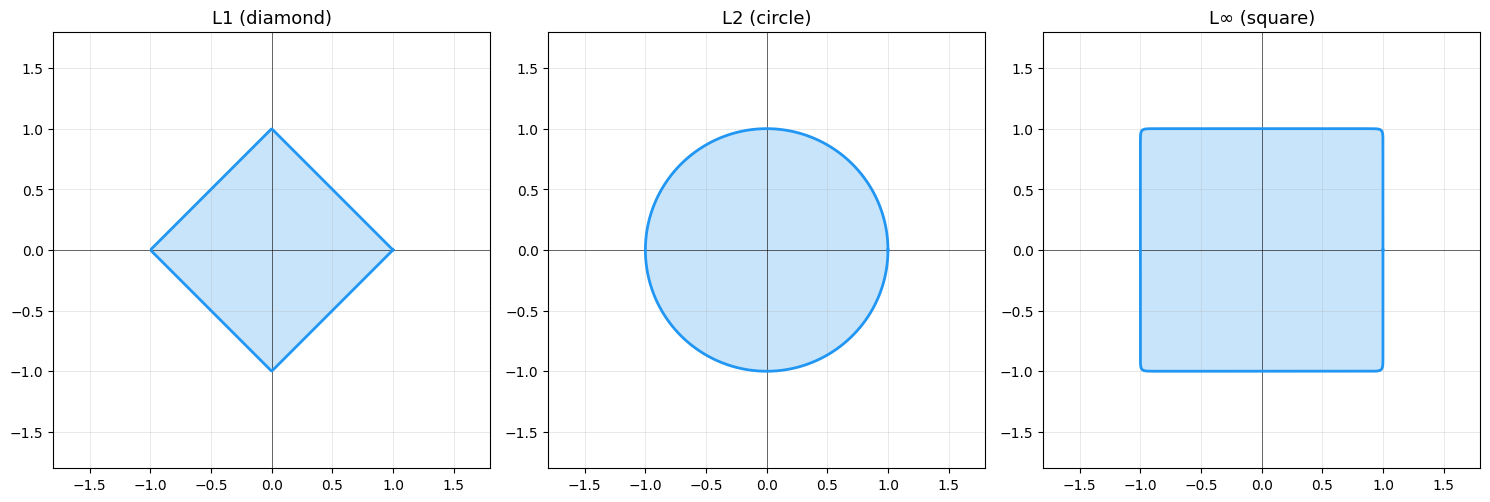

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, p, name in zip(
    axes, [1, 2, 50], ["L1 (diamond)", "L2 (circle)", "L∞ (square)"]
):
    setup_ax(ax, lim=1.8, title=name)
    pts = unit_ball_boundary(p)
    ax.fill(pts[:, 0], pts[:, 1], alpha=0.25, color=BLUE)
    ax.plot(pts[:, 0], pts[:, 1], color=BLUE, lw=2)

plt.tight_layout()
plt.show()

## 4.3 Inner Product -- Angles Between Vectors

The (standard) inner product (dot product) of two vectors is:

$$\langle \mathbf{a}, \mathbf{b} \rangle = \mathbf{a}^T \mathbf{b} = \|\mathbf{a}\| \, \|\mathbf{b}\| \, \cos \theta$$

This directly gives us the **angle** between two vectors:

$$\theta = \arccos \frac{\mathbf{a}^T \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|}$$

Two vectors are **orthogonal** (perpendicular) if and only if $\mathbf{a}^T \mathbf{b} = 0$.

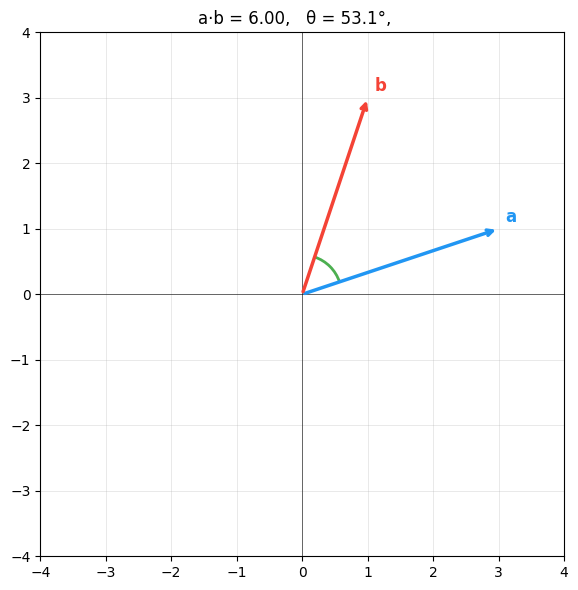

In [5]:
def plot_angle(a, b):
    fig, ax = plt.subplots(figsize=(6, 6))
    setup_ax(ax, lim=4)

    ax.annotate(
        "",
        xy=a,
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=BLUE, lw=2.5),
    )
    ax.annotate(
        "",
        xy=b,
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=RED, lw=2.5),
    )
    ax.text(
        a[0] + 0.1, a[1] + 0.1, "a", color=BLUE, fontsize=12, fontweight="bold"
    )
    ax.text(
        b[0] + 0.1, b[1] + 0.1, "b", color=RED, fontsize=12, fontweight="bold"
    )

    dot = a @ b
    cos_th = dot / (np.linalg.norm(a) * np.linalg.norm(b))
    theta = np.degrees(np.arccos(np.clip(cos_th, -1, 1)))

    from matplotlib.patches import Arc

    angle_a = np.degrees(np.arctan2(a[1], a[0]))
    angle_b = np.degrees(np.arctan2(b[1], b[0]))
    start, end = sorted([angle_a, angle_b])
    if end - start > 180:
        start, end = end, start + 360
    arc = Arc(
        (0, 0), 1.2, 1.2, angle=0, theta1=start, theta2=end, color=GREEN, lw=2
    )
    ax.add_patch(arc)

    ax.set_title(
        f"a·b = {dot:.2f},   θ = {theta:.1f}°,   {'orthogonal!' if abs(dot) < 1e-10 else ''}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


plot_angle(np.array([3, 1]), np.array([1, 3]))

In [6]:
def interactive_angle(ax_, ay, bx, by):
    plot_angle(np.array([ax_, ay]), np.array([bx, by]))


style = {"description_width": "initial"}
widgets.interact(
    interactive_angle,
    ax_=widgets.FloatSlider(
        value=3, min=-4, max=4, step=0.1, description="a_x", style=style
    ),
    ay=widgets.FloatSlider(
        value=1, min=-4, max=4, step=0.1, description="a_y", style=style
    ),
    bx=widgets.FloatSlider(
        value=1, min=-4, max=4, step=0.1, description="b_x", style=style
    ),
    by=widgets.FloatSlider(
        value=3, min=-4, max=4, step=0.1, description="b_y", style=style
    ),
)

interactive(children=(FloatSlider(value=3.0, description='a_x', max=4.0, min=-4.0, style=SliderStyle(descripti…

<function __main__.interactive_angle(ax_, ay, bx, by)>

## 4.4 Projection

The **projection** of $\mathbf{b}$ onto $\mathbf{a}$ is the vector in the direction of $\mathbf{a}$ closest to $\mathbf{b}$:

$$\text{proj}_{\mathbf{a}} \mathbf{b} = \frac{\mathbf{a}^T \mathbf{b}}{\mathbf{a}^T \mathbf{a}} \, \mathbf{a}$$

The residual $\mathbf{b} - \text{proj}_{\mathbf{a}} \mathbf{b}$ is always **orthogonal** to $\mathbf{a}$.

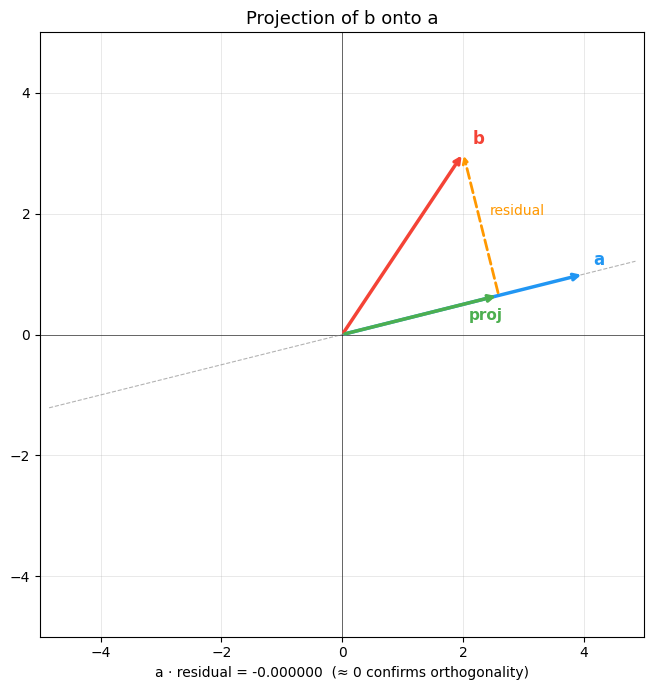

In [7]:
def plot_projection(a, b):
    proj = (a @ b) / (a @ a) * a
    residual = b - proj

    fig, ax = plt.subplots(figsize=(7, 7))
    setup_ax(ax, lim=5, title="Projection of b onto a")

    t = np.linspace(-5, 5, 2)
    direction = a / np.linalg.norm(a)
    ax.plot(
        t * direction[0],
        t * direction[1],
        "--",
        color="gray",
        lw=0.8,
        alpha=0.6,
    )

    ax.annotate(
        "",
        xy=a,
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=BLUE, lw=2.5),
    )
    ax.annotate(
        "",
        xy=b,
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=RED, lw=2.5),
    )
    ax.annotate(
        "",
        xy=proj,
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=GREEN, lw=2.5),
    )
    ax.annotate(
        "",
        xy=b,
        xytext=proj,
        arrowprops=dict(arrowstyle="->", color=ORANGE, lw=2, linestyle="--"),
    )

    ax.text(
        a[0] + 0.15,
        a[1] + 0.15,
        "a",
        color=BLUE,
        fontsize=12,
        fontweight="bold",
    )
    ax.text(
        b[0] + 0.15, b[1] + 0.15, "b", color=RED, fontsize=12, fontweight="bold"
    )
    ax.text(
        proj[0] - 0.5,
        proj[1] - 0.4,
        "proj",
        color=GREEN,
        fontsize=11,
        fontweight="bold",
    )
    ax.text(
        (proj[0] + b[0]) / 2 + 0.15,
        (proj[1] + b[1]) / 2 + 0.15,
        "residual",
        color=ORANGE,
        fontsize=10,
    )

    check = a @ residual
    ax.set_xlabel(
        f"a · residual = {check:.6f}  (≈ 0 confirms orthogonality)", fontsize=10
    )
    plt.tight_layout()
    plt.show()


plot_projection(np.array([4, 1]), np.array([2, 3]))

## 4.5 Matrix Norms (Preview)

We can also assign a "size" to a matrix.  The most common matrix norm is the **spectral norm** (also called the 2-norm):

$$\|A\|_2 = \sigma_{\max}(A) = \text{largest singular value of } A$$

It measures the maximum amount by which $A$ can stretch a unit vector.  
We will revisit this in depth in the SVD notebook.

In [8]:
A = np.array([[3, 1], [0, 2]])
print(f"Matrix A:\n{A}")
print(f"\n  Frobenius norm: {np.linalg.norm(A, 'fro'):.4f}")
print(f"  Spectral norm (2-norm): {np.linalg.norm(A, 2):.4f}")
print(f"  Singular values: {np.linalg.svd(A, compute_uv=False)}")

Matrix A:
[[3 1]
 [0 2]]

  Frobenius norm: 3.7417
  Spectral norm (2-norm): 3.2566
  Singular values: [3.25661654 1.84240298]


In [9]:
A = np.array([[1,1], [1,1.01]])
b = np.array([[2,2.01]]).T
x = np.linalg.solve(A,b)
print(f"x = {x}")
print(f"A @ x = {A @ x}")
print(f"b = {b}")

print(f"L1(A) = {np.linalg.norm(A, 1)}")
print(f"L2(A) = {np.linalg.norm(A, 2)}")
print(f"Linf(A) = {np.linalg.norm(A, np.inf)}")


x = [[1.]
 [1.]]
A @ x = [[2.  ]
 [2.01]]
b = [[2.  ]
 [2.01]]
L1(A) = 2.01
L2(A) = 2.0050124999218757
Linf(A) = 2.01


---

## Exercises

### Exercise 1

Compute the $L^1$, $L^2$, and $L^\infty$ norms of $\mathbf{v} = (1, -2, 3, -4)^T$ by hand, then verify with numpy.  
Confirm the ordering $\|\mathbf{v}\|_\infty \le \|\mathbf{v}\|_2 \le \|\mathbf{v}\|_1$.

<details>
<summary><b>Solution</b></summary>

$\|\mathbf{v}\|_1 = 1+2+3+4 = 10$  
$\|\mathbf{v}\|_2 = \sqrt{1+4+9+16} = \sqrt{30} \approx 5.477$  
$\|\mathbf{v}\|_\infty = 4$  

$4 \le 5.477 \le 10$ &check;

</details>

In [10]:
v = np.array([1, -2, 3, -4])
print(f"L1  = {np.linalg.norm(v, 1):.4f}")
print(f"L2  = {np.linalg.norm(v, 2):.4f}")
print(f"Linf = {np.linalg.norm(v, np.inf):.4f}")

L1  = 10.0000
L2  = 5.4772
Linf = 4.0000


### Exercise 2

Find two vectors $\mathbf{a}$ and $\mathbf{b}$ in $\mathbb{R}^2$ that are orthogonal and each have $L^2$ norm equal to 3.  
Verify that $\mathbf{a}^T \mathbf{b} = 0$ and $\|\mathbf{a}\| = \|\mathbf{b}\| = 3$.

<details>
<summary><b>Solution</b></summary>

Many correct answers. One choice: $\mathbf{a} = (3, 0)^T$, $\mathbf{b} = (0, 3)^T$.  
Another: $\mathbf{a} = (3/\sqrt{2},\; 3/\sqrt{2})^T$, $\mathbf{b} = (3/\sqrt{2},\; -3/\sqrt{2})^T$.

</details>

### Exercise 3

Compute the projection of $\mathbf{b} = (1, 4)^T$ onto $\mathbf{a} = (2, 1)^T$ by hand.  
What is the length of the residual?

<details>
<summary><b>Solution</b></summary>

$\text{proj}_a b = \frac{2 \cdot 1 + 1 \cdot 4}{4 + 1}(2, 1)^T = \frac{6}{5}(2,1)^T = (2.4, 1.2)^T$  
Residual $= (1,4)^T - (2.4, 1.2)^T = (-1.4, 2.8)^T$  
$\|\text{residual}\| = \sqrt{1.96 + 7.84} = \sqrt{9.8} \approx 3.13$

</details>

In [11]:
## For examples

A = np.array([[1,1],[1,1.01]])
b = np.array([[2,2.01]]).T
x = np.linalg.solve(A,b)

b_prime = np.array([[2,2.015]]).T
x_prime = np.linalg.solve(A,b_prime)

print(f"x = {x}")
print(f"x_prime = {x_prime}")

rel_error_b = np.linalg.norm(b_prime - b, np.inf) / np.linalg.norm(b, np.inf    )
print(f"Relative error in b: {rel_error_b*100:.2f}%")

rel_error_x = np.linalg.norm(x_prime - x, np.inf) / np.linalg.norm(x, np.inf)
print(f"Relative error in x: {rel_error_x*100:.2f}%")


np.isclose(np.linalg.det(np.array([[1,1],[1,1.01]])), 0)


x = [[1.]
 [1.]]
x_prime = [[0.5]
 [1.5]]
Relative error in b: 0.25%
Relative error in x: 50.00%


np.False_

In [12]:
## Generate an ill-conditioned matrix
! pip install scipy
from scipy.linalg import hilbert

for n in range(1,4):
    A = hilbert(n)
    print(f"Condition number of hilbert({n}) = {np.linalg.cond(A):.2e}")
    print(f"  det(A) = {np.linalg.det(A):.2e}")

Condition number of hilbert(1) = 1.00e+00
  det(A) = 1.00e+00
Condition number of hilbert(2) = 1.93e+01
  det(A) = 8.33e-02
Condition number of hilbert(3) = 5.24e+02
  det(A) = 4.63e-04
